# Metric Learning sur signaux RFID



> Remarque importante : Cette exploration a été menée par felix.conqui@edu.esiee.fr
>Message de sa part :

>Le metric learning est un domaine que je maîtrisais encore peu. Cependant, grâce notamment au support du cours de M. Chierchia https://perso.esiee.fr/~chierchg/deep-learning/_downloads/7c9cb2798d18d50f25a744143cc8f743/Lecture04.pdf, j’ai pu mener cette exploration. Celle-ci comporte probablement certaines limites, notamment concernant le choix des fonctions de loss, sur lesquelles j’ai rencontré quelques difficultés, ainsi que dans mes tentatives d’évaluer par le code certaines propriétés de l’espace latent (smoothness, clustering, etc.). Malgré cela, j’ai beaucoup apprécié découvrir ce domaine et j’espère avoir davantage de temps à l’avenir pour approfondir mes connaissances et consolider cette exploration.



Dans ce notebook, on apprend une représentation latente à partir des signaux RFID.
L'idée est de combiner :

- une **perte de classification** pour prédire un voxel spatial ;
- une **perte métrique** pour rapprocher les points spatialement proches dans le latent.

On évaluera ensuite si cet espace latent est utile pour :

- la classification des voxels ;
- un k-NN dans l'espace latent ;
- une visualisation 2D des embeddings.

## 1. Imports et configuration

On charge ici les bibliothèques nécessaires pour :

- préparer les données ;
- entraîner le modèle PyTorch ;
- évaluer les performances ;
- visualiser les résultats.

In [1]:
from pathlib import Path
import math
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.decomposition import PCA

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cpu


## 2. Chargement du jeu de données

On charge le CSV, puis on sépare :

- les **entrées** : les signaux RFID ;
- les **sorties continues** : les coordonnées `(x, y, z)`.

On retire explicitement les colonnes qui donnent directement la position ou des indices trop proches de la cible.

In [2]:
DATA_PATH = Path(r"C:\Users\conqu\Documents\WS_RFID\Exploration\ds_Tx.csv")
assert DATA_PATH.exists(), f"Fichier introuvable : {DATA_PATH}"

df = pd.read_csv(DATA_PATH)
print("Shape brute :", df.shape)
display(df.head())

Shape brute : (4411, 64)


,EPC,xyz,max__rssi__24.0__041A9F60__NONE,max__rssi__24.0__041A9F61__NONE,max__rssi__24.0__0F173B12__NONE,max__rssi__24.0__0F173B13__NONE,max__rssi__24.0__PORT_1__NONE,max__rssi__24.0__PORT_2__NONE,max__rssi__24.0__PORT_3__NONE,max__rssi__24.0__PORT_4__NONE,...,041A9F60__NONE,041A9F61__NONE,0F173B12__NONE,0F173B13__NONE,PORT_1__NONE,PORT_2__NONE,PORT_3__NONE,PORT_4__NONE,nearestAnt,nearestD
0,BA0101000000000000000000,1.82__2.51__0.05,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,...,3.695808,3.878273,10.066330,10.405143,5.665421,7.817225,5.455914,7.634592,041A9F60__NONE,3.695808
1,BA0101000000000000000000,10.1__3.82__1.29,0.0,0.0,0.214783,0.000000,0.0,0.807235,0.719449,0.879023,...,7.826270,7.752193,3.633249,3.209751,5.119033,3.061454,5.617517,3.558160,PORT_2__NONE,3.061454
2,BA0101000000000000000000,10.34__3.33__0.05,0.0,0.0,0.000000,0.000000,0.0,0.152757,0.000000,0.212814,...,8.410172,8.437594,4.415314,4.387596,6.066383,4.292901,6.320364,4.483191,PORT_2__NONE,4.292901
3,BA0101000000000000000000,10.51__3.26__0.05,0.0,0.0,0.000000,0.000000,0.0,0.185353,0.000000,0.294442,...,8.553958,8.595941,4.367631,4.368776,6.205336,4.376551,6.431501,4.540947,0F173B12__NONE,4.367631
4,BA0101000000000000000000,10.71__3.92__1.57,0.0,0.0,0.239332,0.203704,0.0,0.133968,0.000000,0.204644,...,8.345502,8.264103,3.378372,2.774779,5.525885,3.213627,6.038990,3.751986,0F173B13__NONE,2.774779


In [3]:
target_cols = ["x", "y", "z"]
drop_cols = [
    "EPC", "xyz", "x", "y", "z", "polar", "nearestAnt", "nearestD"
]

feature_cols = [c for c in df.columns if c not in drop_cols]
X = df[feature_cols].apply(pd.to_numeric, errors="coerce").fillna(0.0).astype(np.float32)
y_xyz = df[target_cols].astype(np.float32).copy()

print("Nombre de features RFID :", len(feature_cols))
print("Features exemple :", feature_cols[:8])
print("Shape X :", X.shape)
print("Shape y_xyz :", y_xyz.shape)

Nombre de features RFID : 56
Features exemple : ['max__rssi__24.0__041A9F60__NONE', 'max__rssi__24.0__041A9F61__NONE', 'max__rssi__24.0__0F173B12__NONE', 'max__rssi__24.0__0F173B13__NONE', 'max__rssi__24.0__PORT_1__NONE', 'max__rssi__24.0__PORT_2__NONE', 'max__rssi__24.0__PORT_3__NONE', 'max__rssi__24.0__PORT_4__NONE']
Shape X : (4411, 56)
Shape y_xyz : (4411, 3)


## 3. Voxelisation de l'espace 3D

On transforme la localisation continue en **problème de classification**.

Principe :

- on choisit une taille de voxel `h` ;
- on discrétise `x`, `y` et `z` ;
- chaque voxel devient une **classe**.

In [4]:
h = 0.75  # taille de voxel ; a ajuster si besoin

mins = y_xyz.min(axis=0)
coords_shifted = y_xyz - mins
voxel_idx = np.floor(coords_shifted.to_numpy() / h).astype(np.int64)

voxel_df = pd.DataFrame(voxel_idx, columns=['vx', 'vy', 'vz'])
assert not voxel_df.isna().any().any(), 'La voxelisation a produit des NaN.'

# Factoriser directement un MultiIndex (evite l'erreur sur liste de tuples)
voxel_labels, voxel_uniques = pd.factorize(pd.MultiIndex.from_frame(voxel_df))
voxel_labels = voxel_labels.astype(np.int64)

num_classes = int(np.unique(voxel_labels).size)
print('Taille de voxel h =', h)
print('Nombre de classes (voxels occupes) :', num_classes)
print('Taille minimale de classe :', pd.Series(voxel_labels).value_counts().min())
display(voxel_df.head())


Taille de voxel h = 0.75
Nombre de classes (voxels occupes) : 118
Taille minimale de classe : 9


,vx,vy,vz
0,0,1,0
1,11,3,1
2,11,2,0
3,11,2,0
4,11,3,2


## 4. Découpage train / test

On fait un split propre avant tout apprentissage :

- `train` pour apprendre l'encodeur et la tête de classification ;
- `test` pour mesurer la généralisation.

On conserve aussi les coordonnées continues, car elles serviront à construire les paires métriques.

In [5]:
X_train, X_test, y_train, y_test, xyz_train, xyz_test = train_test_split(
    X.values,
    voxel_labels,
    y_xyz.values,
    test_size=0.2,
    random_state=SEED,
    stratify=voxel_labels
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
X_test_scaled = scaler.transform(X_test).astype(np.float32)

print("Train :", X_train_scaled.shape, y_train.shape, xyz_train.shape)
print("Test  :", X_test_scaled.shape, y_test.shape, xyz_test.shape)

Train : (3528, 56) (3528,) (3528, 3)
Test  : (883, 56) (883,) (883, 3)


## 5. Tenseurs PyTorch

On convertit les tableaux NumPy en tenseurs pour pouvoir entraîner le réseau.

In [6]:
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
y_test_t = torch.tensor(y_test, dtype=torch.long)
xyz_train_t = torch.tensor(xyz_train, dtype=torch.float32)
xyz_test_t = torch.tensor(xyz_test, dtype=torch.float32)

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=128,
    shuffle=True
)

print(X_train_t.shape, y_train_t.shape, xyz_train_t.shape)

torch.Size([3528, 56]) torch.Size([3528]) torch.Size([3528, 3])


## 6. Modèle : encodeur MLP + tête de classification

Le modèle produit :

- un **embedding** `z` (l'espace latent) ;
- des **logits de classe** pour prédire le voxel.

On pourra faire varier la taille de `z` pour tester plusieurs dimensions latentes.

In [7]:
class MetricMLP(nn.Module):
    def __init__(self, input_dim: int, embedding_dim: int, num_classes: int):
        super().__init__()
        hidden_1 = max(128, input_dim * 2)
        hidden_2 = max(64, input_dim)
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_1),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_1, hidden_2),
            nn.ReLU(),
            nn.Linear(hidden_2, embedding_dim)
        )
        self.classifier = nn.Linear(embedding_dim, num_classes)

    def forward(self, x):
        z = self.encoder(x)
        logits = self.classifier(z)
        return z, logits

## 7. Pertes : classification + métrique

On combine deux objectifs :

- **Cross-Entropy** : bien prédire le voxel ;
- **Contrastive Loss** : rapprocher les points proches dans l'espace réel et éloigner les autres.

La perte totale est :

`L = lambda_1 * CE + lambda_2 * contrastive`

In [8]:
class ContrastiveLoss(nn.Module):
    def __init__(self, margin: float = 1.0):
        super().__init__()
        self.margin = margin

    def forward(self, z1, z2, similar):
        distances = torch.norm(z1 - z2, dim=1)
        positive = similar * distances.pow(2)
        negative = (1.0 - similar) * torch.clamp(self.margin - distances, min=0.0).pow(2)
        return (positive + negative).mean()


contrastive_loss_fn = ContrastiveLoss(margin=1.0)
ce_loss_fn = nn.CrossEntropyLoss()

## 8. Construction des paires métriques

On définit des paires à partir de la **proximité spatiale réelle** :

- paire positive : distance euclidienne dans l'espace `(x,y,z)` inférieure à un seuil ;
- paire négative : distance supérieure à ce seuil.

Cela permet de guider le latent avec une notion géométrique simple.

In [9]:
def sample_pairs(x_tensor, xyz_tensor, distance_threshold, num_pairs=4096, seed=42):
    rng = np.random.default_rng(seed)
    n = x_tensor.shape[0]
    i_idx = rng.integers(0, n, size=num_pairs)
    j_idx = rng.integers(0, n, size=num_pairs)

    xyz_i = xyz_tensor[i_idx].numpy()
    xyz_j = xyz_tensor[j_idx].numpy()
    spatial_dist = np.linalg.norm(xyz_i - xyz_j, axis=1)
    similar = (spatial_dist <= distance_threshold).astype(np.float32)

    pair_data = {
        "x1": x_tensor[i_idx],
        "x2": x_tensor[j_idx],
        "similar": torch.tensor(similar, dtype=torch.float32)
    }
    return pair_data


distance_threshold = 1.5 * h
pairs_train = sample_pairs(X_train_t, xyz_train_t, distance_threshold, num_pairs=6000, seed=SEED)

print("Seuil de proximité spatiale :", distance_threshold)
print("Proportion de paires positives :", pairs_train["similar"].mean().item())

Seuil de proximité spatiale : 1.125
Proportion de paires positives : 0.07400000095367432


## 9. Boucle d'entraînement

À chaque époque :

- on entraîne le classifieur sur les batchs standards ;
- on calcule aussi une perte contrastive sur les paires ;
- on combine les deux.

On suivra la loss totale ainsi que l'accuracy de test.

In [10]:
def make_pair_loader(pair_dict, batch_size=256, shuffle=True):
    dataset = TensorDataset(pair_dict["x1"], pair_dict["x2"], pair_dict["similar"])
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)


def evaluate_model(model, x_train, y_train, x_test, y_test, n_neighbors=5):
    model.eval()
    with torch.no_grad():
        z_train, logits_train = model(x_train.to(DEVICE))
        z_test, logits_test = model(x_test.to(DEVICE))

    z_train_np = z_train.cpu().numpy()
    z_test_np = z_test.cpu().numpy()
    logits_test_np = logits_test.cpu().numpy()

    y_pred_cls = logits_test_np.argmax(axis=1)
    cls_acc = accuracy_score(y_test, y_pred_cls)

    knn = KNeighborsClassifier(n_neighbors=n_neighbors)
    knn.fit(z_train_np, y_train)
    y_pred_knn = knn.predict(z_test_np)
    knn_acc = accuracy_score(y_test, y_pred_knn)

    return {
        "classification_accuracy": cls_acc,
        "knn_accuracy": knn_acc,
        "z_train": z_train_np,
        "z_test": z_test_np,
        "y_pred_cls": y_pred_cls,
        "y_pred_knn": y_pred_knn
    }


def train_one_dimension(
    embedding_dim,
    x_train,
    y_train_tensor,
    x_test,
    y_test_np,
    pair_dict,
    num_classes,
    lambda_ce=1.0,
    lambda_metric=0.5,
    epochs=25,
    lr=1e-3,
    batch_size=128
):
    model = MetricMLP(x_train.shape[1], embedding_dim, num_classes).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

    cls_loader = DataLoader(TensorDataset(x_train, y_train_tensor), batch_size=batch_size, shuffle=True)
    pair_loader = make_pair_loader(pair_dict, batch_size=256, shuffle=True)

    history = {"loss": [], "ce": [], "metric": [], "test_acc": [], "test_knn": []}

    for epoch in range(epochs):
        model.train()
        cls_iter = iter(cls_loader)
        pair_iter = iter(pair_loader)
        steps = max(len(cls_loader), len(pair_loader))

        epoch_loss = 0.0
        epoch_ce = 0.0
        epoch_metric = 0.0

        for _ in range(steps):
            try:
                xb, yb = next(cls_iter)
            except StopIteration:
                cls_iter = iter(cls_loader)
                xb, yb = next(cls_iter)

            try:
                x1, x2, s = next(pair_iter)
            except StopIteration:
                pair_iter = iter(pair_loader)
                x1, x2, s = next(pair_iter)

            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            x1, x2, s = x1.to(DEVICE), x2.to(DEVICE), s.to(DEVICE)

            optimizer.zero_grad()

            _, logits = model(xb)
            ce = ce_loss_fn(logits, yb)

            z1, _ = model(x1)
            z2, _ = model(x2)
            metric = contrastive_loss_fn(z1, z2, s)

            loss = lambda_ce * ce + lambda_metric * metric
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            epoch_ce += ce.item()
            epoch_metric += metric.item()

        metrics = evaluate_model(model, x_train, y_train_tensor.cpu().numpy(), x_test, y_test_np)
        history["loss"].append(epoch_loss / steps)
        history["ce"].append(epoch_ce / steps)
        history["metric"].append(epoch_metric / steps)
        history["test_acc"].append(metrics["classification_accuracy"])
        history["test_knn"].append(metrics["knn_accuracy"])

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(
                f"[dim={embedding_dim:>3}] epoch {epoch+1:02d}/{epochs} | "
                f"loss={history['loss'][-1]:.4f} | ce={history['ce'][-1]:.4f} | "
                f"metric={history['metric'][-1]:.4f} | "
                f"acc={history['test_acc'][-1]:.4f} | knn={history['test_knn'][-1]:.4f}"
            )

    final_metrics = evaluate_model(model, x_train, y_train_tensor.cpu().numpy(), x_test, y_test_np)
    return model, history, final_metrics

## 10. Expériences sur plusieurs dimensions latentes

On teste plusieurs tailles d'embedding :

- plus petites que l'entrée ;
- proches de l'entrée ;
- plus grandes que l'entrée.

Cela permet de voir si compresser ou au contraire élargir l'espace aide la tâche.

In [11]:
embedding_dims = [8, 16, 32, 64, 128]
lambda_1 = 1.0
lambda_2 = 0.5
epochs = 25

results = []
artifacts = {}

for emb_dim in embedding_dims:
    model, history, metrics = train_one_dimension(
        embedding_dim=emb_dim,
        x_train=X_train_t,
        y_train_tensor=y_train_t,
        x_test=X_test_t,
        y_test_np=y_test,
        pair_dict=pairs_train,
        num_classes=num_classes,
        lambda_ce=lambda_1,
        lambda_metric=lambda_2,
        epochs=epochs,
        lr=1e-3,
        batch_size=128
    )

    results.append({
        "embedding_dim": emb_dim,
        "classification_accuracy": metrics["classification_accuracy"],
        "knn_accuracy": metrics["knn_accuracy"]
    })
    artifacts[emb_dim] = {
        "model": model,
        "history": history,
        "metrics": metrics
    }

results_df = pd.DataFrame(results).sort_values("embedding_dim").reset_index(drop=True)
print("Résultats par dimension :")
display(results_df)

[dim=  8] epoch 01/25 | loss=4.8906 | ce=4.7754 | metric=0.2304 | acc=0.0328 | knn=0.3828


[dim=  8] epoch 05/25 | loss=4.1300 | ce=4.0648 | metric=0.1305 | acc=0.0815 | knn=0.5357


[dim=  8] epoch 10/25 | loss=3.4953 | ce=3.3351 | metric=0.3204 | acc=0.1925 | knn=0.6274


[dim=  8] epoch 15/25 | loss=3.1154 | ce=2.8801 | metric=0.4706 | acc=0.2741 | knn=0.6931


[dim=  8] epoch 20/25 | loss=2.7923 | ce=2.5064 | metric=0.5718 | acc=0.3216 | knn=0.7452


...

[dim=128] epoch 10/25 | loss=2.5388 | ce=2.2568 | metric=0.5639 | acc=0.4088 | knn=0.7271


[dim=128] epoch 15/25 | loss=2.0789 | ce=1.7408 | metric=0.6763 | acc=0.5391 | knn=0.8211


[dim=128] epoch 20/25 | loss=1.7521 | ce=1.4010 | metric=0.7022 | acc=0.6399 | knn=0.8381


[dim=128] epoch 25/25 | loss=1.5552 | ce=1.1964 | metric=0.7175 | acc=0.6795 | knn=0.8528
Résultats par dimension :


,embedding_dim,classification_accuracy,knn_accuracy
0,8,0.407701,0.778029
1,16,0.465459,0.831257
2,32,0.560589,0.840317
3,64,0.630804,0.867497
4,128,0.679502,0.852775


## 11. Courbes de performance selon la taille du latent

On trace ici les performances pour voir si certaines tailles d'embedding sont plus adaptées.

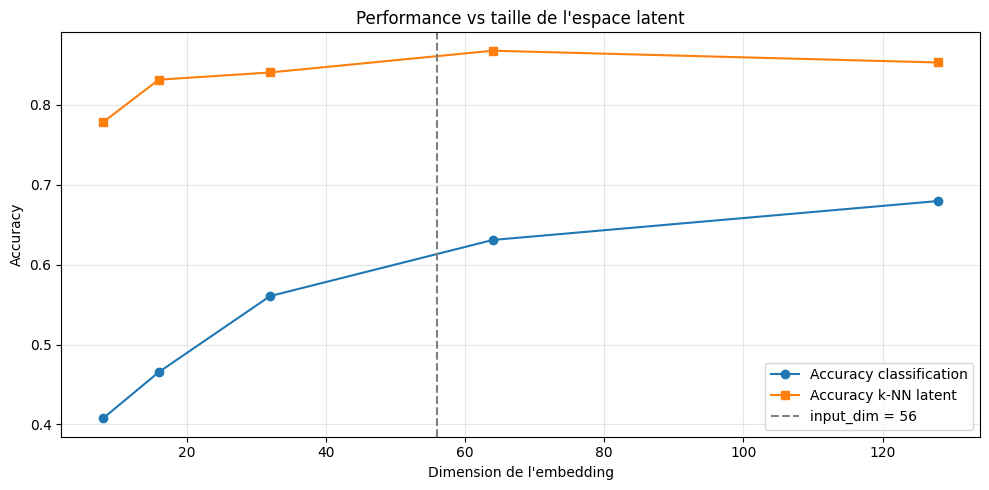

In [12]:
plt.figure(figsize=(10, 5))
plt.plot(results_df["embedding_dim"], results_df["classification_accuracy"], marker="o", label="Accuracy classification")
plt.plot(results_df["embedding_dim"], results_df["knn_accuracy"], marker="s", label="Accuracy k-NN latent")
plt.axvline(X_train_t.shape[1], color="gray", linestyle="--", label=f"input_dim = {X_train_t.shape[1]}")
plt.xlabel("Dimension de l'embedding")
plt.ylabel("Accuracy")
plt.title("Performance vs taille de l'espace latent")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 12. Historique d'entraînement du meilleur modèle

On récupère la dimension qui donne la meilleure accuracy de classification, puis on visualise :

- la loss totale ;
- la composante classification ;
- la composante métrique ;
- les performances test.

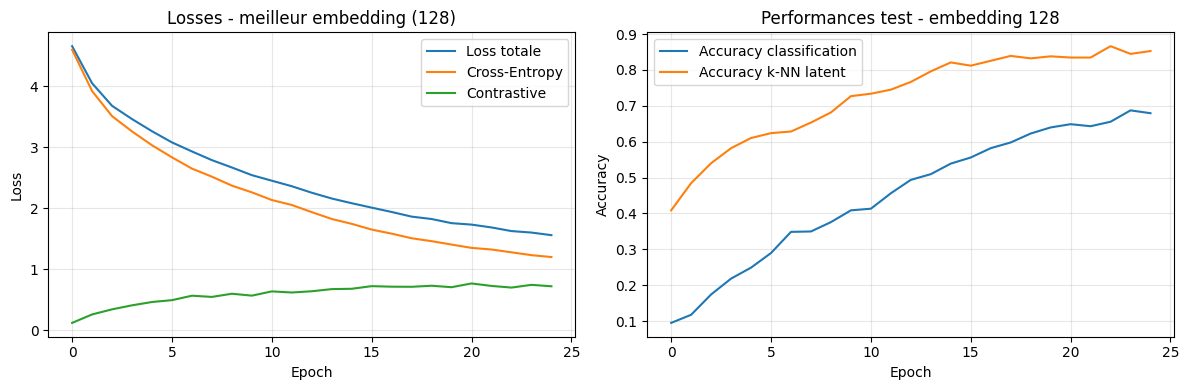

In [13]:
best_dim = results_df.sort_values("classification_accuracy", ascending=False).iloc[0]["embedding_dim"]
best_dim = int(best_dim)
best_history = artifacts[best_dim]["history"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(best_history["loss"], label="Loss totale")
axes[0].plot(best_history["ce"], label="Cross-Entropy")
axes[0].plot(best_history["metric"], label="Contrastive")
axes[0].set_title(f"Losses - meilleur embedding ({best_dim})")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(best_history["test_acc"], label="Accuracy classification")
axes[1].plot(best_history["test_knn"], label="Accuracy k-NN latent")
axes[1].set_title(f"Performances test - embedding {best_dim}")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

## 13. Visualisation 2D du latent

Pour mieux comprendre ce que le modèle apprend, on projette le latent en 2D avec PCA.

Ce n'est pas une preuve formelle, mais cela aide à voir si les voxels semblent séparés visuellement.

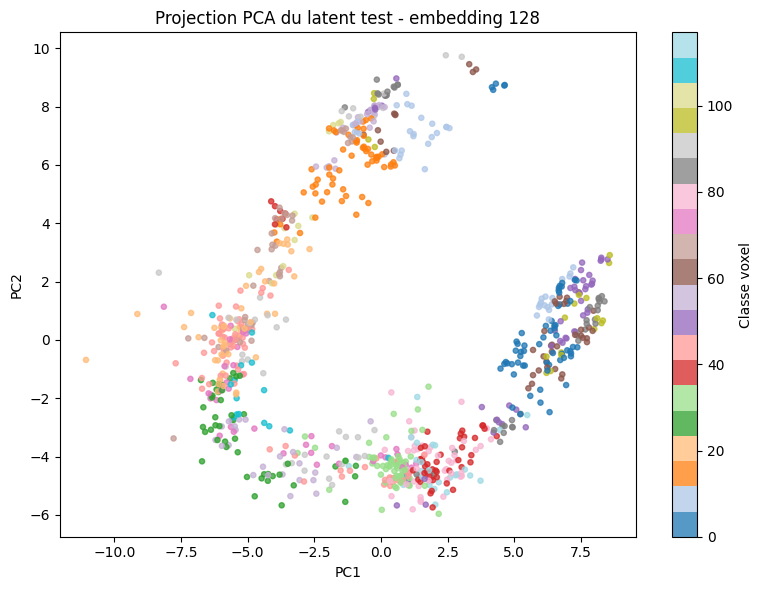

In [14]:
best_metrics = artifacts[best_dim]["metrics"]
z_test_best = best_metrics["z_test"]

pca = PCA(n_components=2, random_state=SEED)
z_test_2d = pca.fit_transform(z_test_best)

plt.figure(figsize=(8, 6))
sc = plt.scatter(
    z_test_2d[:, 0],
    z_test_2d[:, 1],
    c=y_test,
    cmap="tab20",
    s=14,
    alpha=0.75
)
plt.colorbar(sc, label="Classe voxel")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"Projection PCA du latent test - embedding {best_dim}")
plt.tight_layout()
plt.show()

## 14. Bilan final

On résume les résultats principaux :

- quelle dimension latente fonctionne le mieux ;
- si le latent aide bien la classification ;
- si le k-NN dans l'espace latent reste cohérent.

In [15]:
best_row = results_df.sort_values("classification_accuracy", ascending=False).iloc[0]
best_knn_row = results_df.sort_values("knn_accuracy", ascending=False).iloc[0]

print("Meilleure dimension pour la classification :", int(best_row["embedding_dim"]))
print("Accuracy classification associée        :", round(float(best_row["classification_accuracy"]), 4))
print()
print("Meilleure dimension pour le k-NN latent :", int(best_knn_row["embedding_dim"]))
print("Accuracy k-NN associée                  :", round(float(best_knn_row["knn_accuracy"]), 4))
print()
print("Tableau récapitulatif :")
display(results_df)

Meilleure dimension pour la classification : 128
Accuracy classification associée        : 0.6795

Meilleure dimension pour le k-NN latent : 64
Accuracy k-NN associée                  : 0.8675

Tableau récapitulatif :


,embedding_dim,classification_accuracy,knn_accuracy
0,8,0.407701,0.778029
1,16,0.465459,0.831257
2,32,0.560589,0.840317
3,64,0.630804,0.867497
4,128,0.679502,0.852775


## 15. Test simple de smoothness et clustering pour l'embedding 64

Dans cette partie, on regarde deux propriétés simples du latent de dimension `64` :

- **Smoothness** : si on perturbe légèrement l'entrée, le latent doit peu bouger ;
- **Clustering** : les points d'une même classe doivent être plus proches entre eux que des points de classes différentes.

Le but ici est d'avoir un test lisible et directement interprétable.

=== Smoothness (embedding 64) ===
Bruit ajouté sur l'entrée (std)        : 0.05
||delta_x|| moyen                      : 0.3716
||delta_z|| moyen                      : 0.4493
Ratio moyen ||delta_z|| / ||delta_x||  : 1.2103
Interprétation : plus ce ratio est petit, plus le latent est localement stable.


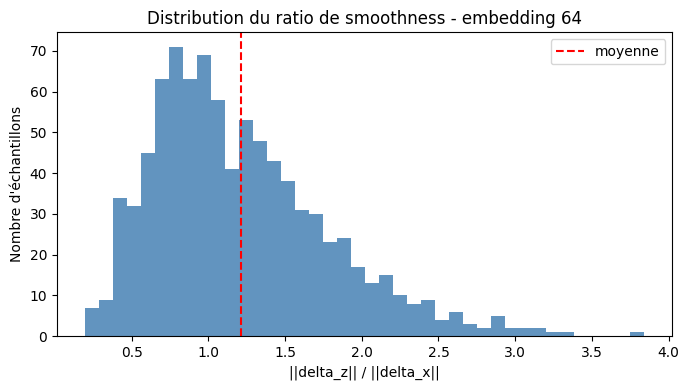


=== Clustering (embedding 64) ===
Distance intra-classe moyenne : 2.3390
Distance inter-classe moyenne : 11.3678
Ratio intra / inter           : 0.2058
Silhouette score              : 0.1372
Interprétation : on veut une intra-classe faible, une inter-classe élevée, un ratio faible et un silhouette score élevé.


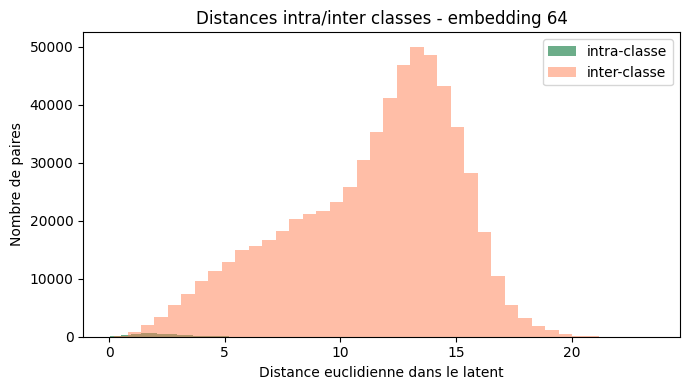

In [16]:
from sklearn.metrics import silhouette_score
from sklearn.metrics import pairwise_distances

# On récupère le modèle et les embeddings associés à la dimension 64.
model_64 = artifacts[64]["model"]
metrics_64 = artifacts[64]["metrics"]
z_train_64 = metrics_64["z_train"]
z_test_64 = metrics_64["z_test"]

# ------------------------------------------------------------
# 1) Smoothness
# ------------------------------------------------------------
# Idée : on ajoute un petit bruit gaussien sur X_test, puis on compare
# le latent original et le latent perturbé.
noise_std = 0.05
x_test_noisy = X_test_t + noise_std * torch.randn_like(X_test_t)

model_64.eval()
with torch.no_grad():
    z_test_ref, _ = model_64(X_test_t.to(DEVICE))
    z_test_noisy, _ = model_64(x_test_noisy.to(DEVICE))

z_test_ref = z_test_ref.cpu().numpy()
z_test_noisy = z_test_noisy.cpu().numpy()
x_test_np = X_test_t.numpy()
x_test_noisy_np = x_test_noisy.numpy()

delta_x = np.linalg.norm(x_test_noisy_np - x_test_np, axis=1)
delta_z = np.linalg.norm(z_test_noisy - z_test_ref, axis=1)
smoothness_ratio = delta_z / (delta_x + 1e-8)

print("=== Smoothness (embedding 64) ===")
print(f"Bruit ajouté sur l'entrée (std)        : {noise_std}")
print(f"||delta_x|| moyen                      : {delta_x.mean():.4f}")
print(f"||delta_z|| moyen                      : {delta_z.mean():.4f}")
print(f"Ratio moyen ||delta_z|| / ||delta_x||  : {smoothness_ratio.mean():.4f}")
print("Interprétation : plus ce ratio est petit, plus le latent est localement stable.")

plt.figure(figsize=(7, 4))
plt.hist(smoothness_ratio, bins=40, color="steelblue", alpha=0.85)
plt.axvline(smoothness_ratio.mean(), color="red", linestyle="--", label="moyenne")
plt.title("Distribution du ratio de smoothness - embedding 64")
plt.xlabel("||delta_z|| / ||delta_x||")
plt.ylabel("Nombre d'échantillons")
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 2) Clustering
# ------------------------------------------------------------
# Idée : comparer les distances entre points d'une même classe
# et les distances entre classes différentes.
sample_size = min(800, len(z_test_64))
rng = np.random.default_rng(SEED)
sample_idx = rng.choice(len(z_test_64), size=sample_size, replace=False)

z_sample = z_test_64[sample_idx]
y_sample = y_test[sample_idx]
dist_mat = pairwise_distances(z_sample, metric="euclidean")

same_mask = y_sample[:, None] == y_sample[None, :]
diff_mask = ~same_mask
np.fill_diagonal(same_mask, False)
np.fill_diagonal(diff_mask, False)

intra_dist = dist_mat[same_mask]
inter_dist = dist_mat[diff_mask]
sil_score = silhouette_score(z_sample, y_sample, metric="euclidean")

print("\n=== Clustering (embedding 64) ===")
print(f"Distance intra-classe moyenne : {intra_dist.mean():.4f}")
print(f"Distance inter-classe moyenne : {inter_dist.mean():.4f}")
print(f"Ratio intra / inter           : {intra_dist.mean() / (inter_dist.mean() + 1e-8):.4f}")
print(f"Silhouette score              : {sil_score:.4f}")
print("Interprétation : on veut une intra-classe faible, une inter-classe élevée, un ratio faible et un silhouette score élevé.")

plt.figure(figsize=(7, 4))
plt.hist(intra_dist, bins=40, alpha=0.7, label="intra-classe", color="seagreen")
plt.hist(inter_dist, bins=40, alpha=0.5, label="inter-classe", color="coral")
plt.title("Distances intra/inter classes - embedding 64")
plt.xlabel("Distance euclidienne dans le latent")
plt.ylabel("Nombre de paires")
plt.legend()
plt.tight_layout()
plt.show()